# 02 — Comparaison des LLM

## Objectif

Comparer plusieurs modèles de langage (LLM) avec les mêmes paramètres
d'embedding et de retrieval.

**Question de recherche :** Quel LLM offre la meilleure qualité
pour l'assistant virtuel académique ?

**Paramètres fixes :**
- Embedding : BAAI/bge-m3
- Retrieval : top_k=3
- Benchmark : 5 questions

---
**Pourquoi cette comparaison est importante :**
Le choix du LLM impacte directement la qualité, le coût et le temps
de réponse. Comparer plusieurs modèles permet de justifier objectivement
le choix retenu.

## 1. Imports

In [1]:
import sys
from pathlib import Path
import time

ROOT = Path.cwd()
for _ in range(4):
    if (ROOT / "src").exists():
        break
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT))

from config import LLMConfig, RetrievalConfig, EmbeddingConfig
from retriever import retrieve_documents
from llm_chain import generate_answer
from evaluation_judge import create_judge
from deepeval.test_case import LLMTestCase
from deepeval.metrics import FaithfulnessMetric, AnswerRelevancyMetric

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

print("✅ Imports réussis")

✅ Imports réussis


## 2. Paramètres fixes

Ces paramètres restent identiques pour tous les LLM testés.

In [2]:
emb_cfg = EmbeddingConfig(provider="huggingface", model="BAAI/bge-m3", device="cpu")
ret_cfg = RetrievalConfig(top_k=3, max_distance=1.5)

print(f"🔤 Embedding : {emb_cfg.provider}:{emb_cfg.model}")
print(f"📄 Retrieval : top_k={ret_cfg.top_k}")

🔤 Embedding : huggingface:BAAI/bge-m3
📄 Retrieval : top_k=3


## 3. Liste des LLM à comparer

Modifie cette liste pour ajouter ou retirer des modèles.
Tous les modèles sont accessibles via OpenRouter.

In [3]:
MODELS = [
    ("Gemini Flash",   "google/gemini-2.5-flash"),
    ("Gemini Pro",     "google/gemini-2.5-pro"),
    ("DeepSeek",       "deepseek/deepseek-chat"),
    ("Qwen 2.5 72B",   "qwen/qwen-2.5-72b-instruct"),
    ("Llama 3.3 70B",  "meta-llama/llama-3.3-70b-instruct"),
]

print(f"📋 {len(MODELS)} modèle(s) à comparer :")
for name, model_id in MODELS:
    print(f"   - {name:15s} → {model_id}")

📋 5 modèle(s) à comparer :
   - Gemini Flash    → google/gemini-2.5-flash
   - Gemini Pro      → google/gemini-2.5-pro
   - DeepSeek        → deepseek/deepseek-chat
   - Qwen 2.5 72B    → qwen/qwen-2.5-72b-instruct
   - Llama 3.3 70B   → meta-llama/llama-3.3-70b-instruct


## 4. Questions de test

5 questions représentatives de différents niveaux de difficulté.

In [5]:
QUESTIONS = [
    ("Q01", "Quelle est la note minimale pour valider un module ?",
     "L'étudiant doit obtenir une note finale >= 5,5/10"),
    ("Q02", "Quel est le montant des frais de prolongation ?",
     "Les frais de prolongation sont de 1 000 000 VND par mois"),
    ("Q03", "Peut-on demander une prolongation du mémoire ?",
     "Oui, avec une demande écrite au Service de scolarité"),
    ("Q04", "Quel est le délai de préavis pour résilier le contrat ?",
     "90 jours"),
    ("Q05", "Comment se déroule la soutenance de mémoire ?",
     "L'étudiant présente son travail devant un jury"),
]

print(f"📚 {len(QUESTIONS)} questions de test")

📚 5 questions de test


## 5. Configuration du juge DeepEval

Le juge est le modèle qui évalue la qualité des réponses.
On utilise Gemini Flash comme juge pour tous les tests.

In [6]:
judge = create_judge(provider="ollama", model="qwen2.5:3b")
print(f"⚖️  Juge : {judge.get_model_name()}")

⚖️  Juge : qwen2.5:3b


## 6. Boucle d'évaluation

Pour chaque LLM :
1. On pose chaque question
2. On récupère les chunks (retrieval)
3. On génère une réponse
4. On calcule les métriques DeepEval

**Attention :** cette boucle peut prendre plusieurs minutes.

In [7]:
results = []

for llm_name, model_id in MODELS:
    print(f"\n{'='*60}")
    print(f"  🔄 Test : {llm_name}")
    print(f"{'='*60}")

    llm_cfg = LLMConfig(
        provider="openrouter", model=model_id,
        temperature=0.2, num_predict=512, request_timeout=120,
    )

    for qid, question, expected in QUESTIONS:
        try:
            docs, scores = retrieve_documents(question, ret_cfg, emb_cfg)
            start = time.time()
            answer = generate_answer(question, docs, llm_cfg)
            elapsed = time.time() - start

            test_case = LLMTestCase(
                input=question,
                actual_output=answer,
                expected_output=expected,
                retrieval_context=[d.page_content for d in docs],
            )

            faith = FaithfulnessMetric(threshold=0.75, model=judge, include_reason=True)
            relev = AnswerRelevancyMetric(threshold=0.75, model=judge, include_reason=True)

            try:
                faith.measure(test_case)
            except Exception:
                faith.score = 0.0
            try:
                relev.measure(test_case)
            except Exception:
                relev.score = 0.0

            results.append({
                "Modèle": llm_name,
                "Question": qid,
                "Faithfulness": round(faith.score, 4),
                "AnswerRelevancy": round(relev.score, 4),
                "Temps(s)": round(elapsed, 2),
                "Chunks": len(docs),
            })
            print(f"   [{qid}] Faith={faith.score:.3f}  Relev={relev.score:.3f}  ({elapsed:.1f}s)")

        except Exception as e:
            print(f"   [{qid}] ❌ Erreur : {e}")
            results.append({
                "Modèle": llm_name,
                "Question": qid,
                "Faithfulness": 0.0,
                "AnswerRelevancy": 0.0,
                "Temps(s)": 0.0,
                "Chunks": 0,
            })

df = pd.DataFrame(results)
print(f"\n✅ Évaluation terminée : {len(df)} mesures")


  🔄 Test : Gemini Flash


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Output()

Output()

   [Q01] Faith=0.000  Relev=0.500  (1.3s)


...

   [Q04] Faith=0.000  Relev=0.000  (1.1s)


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Output()

Output()

   [Q05] Faith=0.000  Relev=0.500  (4.7s)

✅ Évaluation terminée : 25 mesures


## 7. Tableau comparatif

Moyennes des métriques par modèle LLM.
**Lecture :** plus le score est proche de 1.0, meilleure est la qualité.

In [8]:
summary = df.groupby("Modèle")[["Faithfulness", "AnswerRelevancy", "Temps(s)"]].mean().round(4)
summary.columns = ["Fidélité", "Pertinence", "Temps (s)"]
summary

,Fidélité,Pertinence,Temps (s)
Modèle,,,
DeepSeek,0.2,0.3200,2.476
Gemini Flash,0.0,0.1000,2.022
Gemini Pro,0.0,0.1000,6.084
Llama 3.3 70B,0.0,0.3333,2.110
Qwen 2.5 72B,0.0,0.1467,4.220


## 8. Graphique comparatif

Visualisation des scores par LLM.

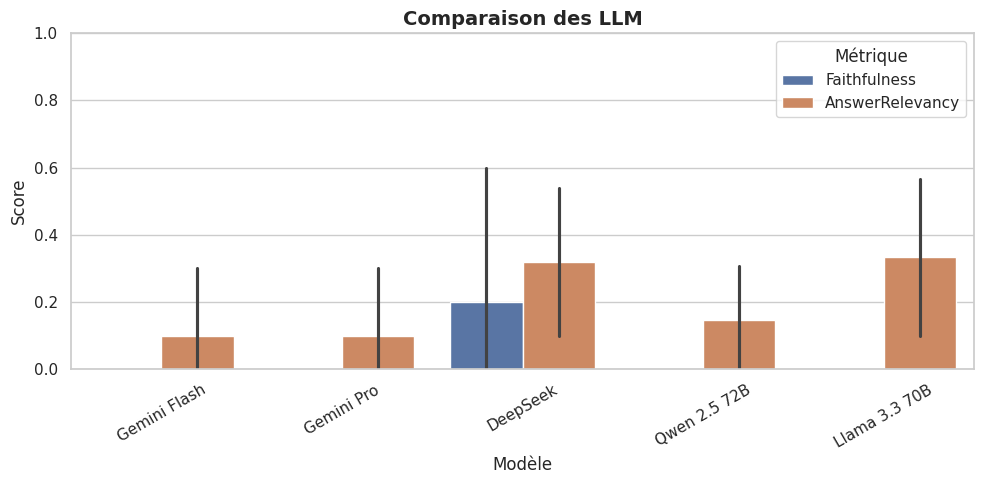

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = df.melt(id_vars=["Modèle"], value_vars=["Faithfulness", "AnswerRelevancy"],
                  var_name="Métrique", value_name="Score")
sns.barplot(data=plot_df, x="Modèle", y="Score", hue="Métrique", ax=ax)
ax.set_title("Comparaison des LLM", fontsize=14, fontweight="bold")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## 9. Export CSV

Sauvegarde des résultats pour le notebook de synthèse.

In [10]:
out_dir = ROOT / "evaluation" / "results"
out_dir.mkdir(parents=True, exist_ok=True)
df.to_csv(out_dir / "02_compare_llms.csv", index=False)
summary.to_csv(out_dir / "02_compare_llms_summary.csv")
print(f"✅ Exporté dans {out_dir}/")

✅ Exporté dans /home/ibrahim/MyProjets/Projets_de_Stage/evaluation/results/


## 10. Analyse

**Comment choisir le meilleur LLM :**
- **Fidélité > 0.8** : la réponse utilise correctement le contexte
- **Pertinence > 0.8** : la réponse est bien adaptée à la question
- **Temps bas** : meilleure expérience utilisateur

**Recommandation :** privilégier le modèle qui maximise la fidélité
tout en restant rapide.